In [113]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [115]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
import pandas as pd
from sklearn.preprocessing import  LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.model_selection import  train_test_split, GridSearchCV
from sklearn.metrics import  classification_report,confusion_matrix_at_thresholds
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


load the employee attrition dataset


In [118]:
df=pd.read_csv("C:\\Users\\balla\\fullstack\\project1\\HR_Employee_Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


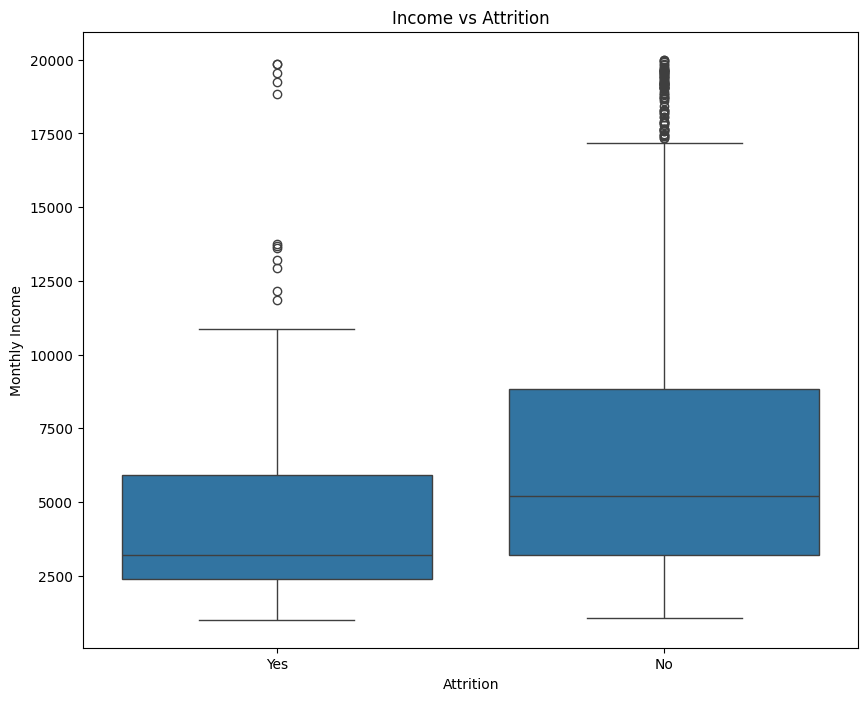

In [119]:
plt.figure(figsize=(10,8))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)
plt.title("Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

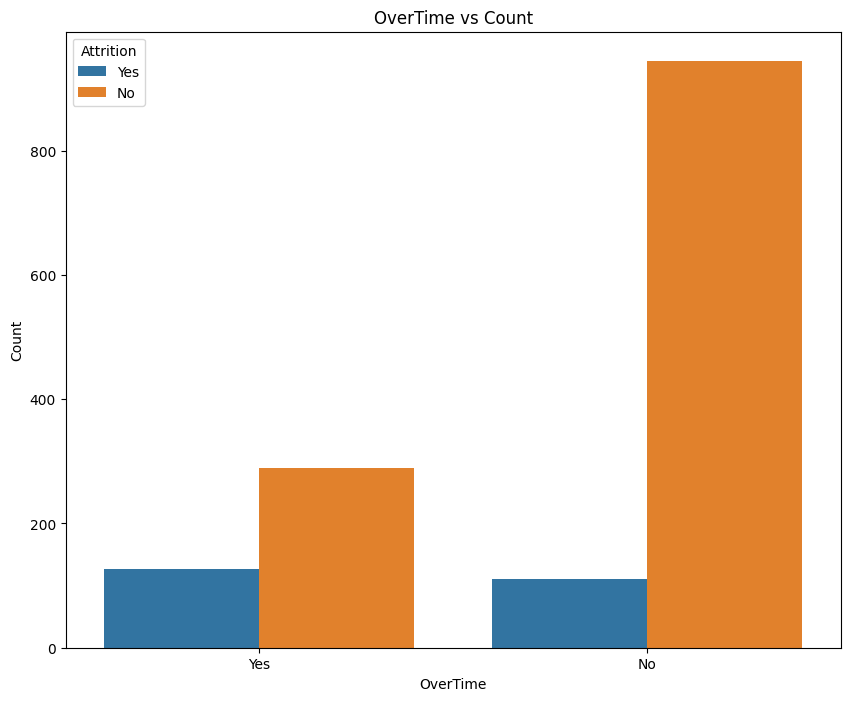

In [120]:
plt.figure(figsize=(10,8))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Count")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.show()

In [121]:
#df.drop(["EmployeeNumber","EmployeeCount","Over18","StandardHours"], axis=1,inplace=True)
encoder={}
for col in df.select_dtypes(include=["object"]).columns:
    lb=LabelEncoder()
    df[col]=lb.fit_transform(df[col])
    encoder[col]=lb
    X=df.drop("Attrition",axis=1)
    y=df["Attrition"]
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=42)

In [122]:
rf=RandomForestClassifier(random_state=42)
param_grid={
    "n_estimators":[50,100],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2],
}
grid_search=GridSearchCV(rf,param_grid,cv=5,scoring='f1')
grid_search.fit(X_train,y_train)
print("Best Hyperparameters:",grid_search.best_params_)

Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [123]:
model=RandomForestClassifier(**grid_search.best_params_,random_state=42)
model.fit(X,y)
joblib.dump(model,"employee_attrition_model.pkl")
joblib.dump(encoder,"label_encoder.pkl")
joblib.dump(X.columns.to_list(),"feature_columns.pkl")

['feature_columns.pkl']

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       507
           1       0.75      0.15      0.25        81

    accuracy                           0.88       588
   macro avg       0.81      0.57      0.59       588
weighted avg       0.86      0.88      0.84       588

[[503   4]
 [ 69  12]]


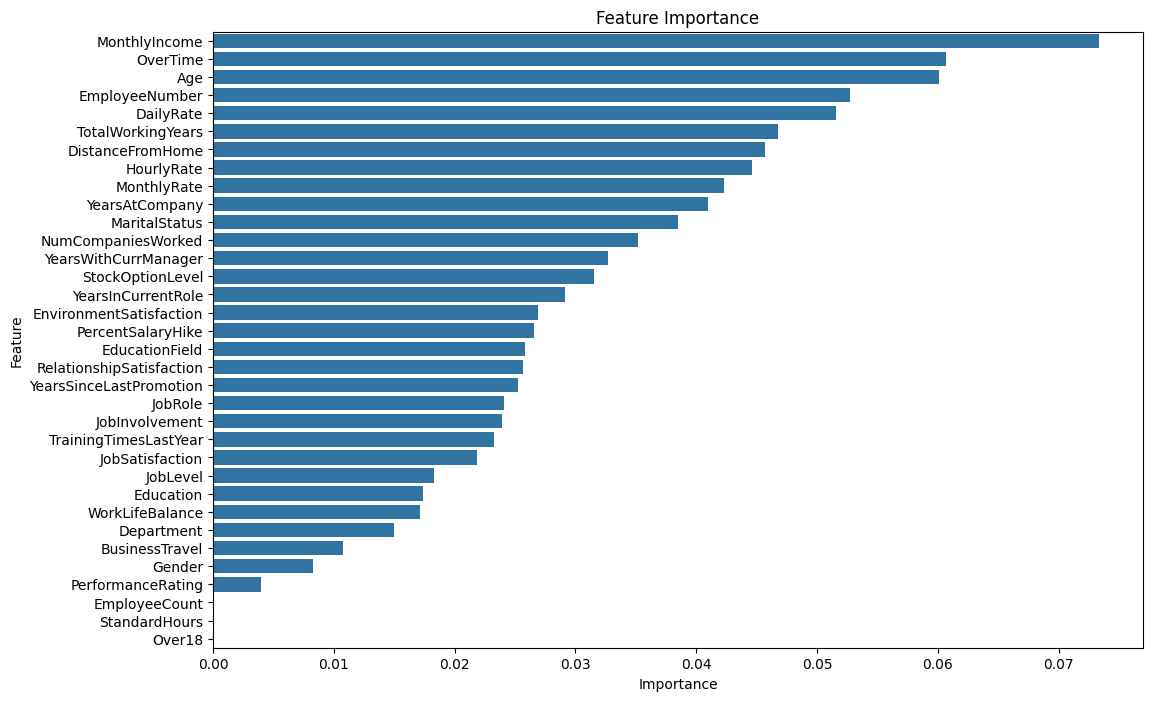

In [124]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = grid_search.best_estimator_

predictions = best_model.predict(X_test)

print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()